# `Matplotlib` 資料視覺化

`matplotlib` 幾乎是標準 Python 畫圖套件了! 在有 `matplotlib` 之前, Python 要畫圖不那麼方便, 和 Python 很多套件一樣, 有許多方案, 但各家有不同的優缺點, 也沒有一套是大家都在用的。

而 `matplotlib` 仿 Matlab 式的畫圖方式, 讓很多人很快入手、並且功能相當完整。原作者是 John D. Hunter, 和很多 Python 的套件作者一樣, 他有博士學位。非常令人遺憾的是他在 2012 年因大腸直腸癌治療併發症過逝, 過逝時才 44 歲!


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt


## 1 畫個函數

前面說過 `plt.plot` 的基本用法是

    plt.plot(X,Y)

其中 X, Y 是分別是點 x 座標, y 座標形的的 list 或 array。

### 【重點】標準函數畫法

函數畫圖其實就是描點法, 而且再次用到陣列導向計算的概念。

我們先牛刀小試, 畫個 $\sin$ 的圖。

$$f(x) = \sin(x)$$

先來設個 x 的範圍, 就 -10 到 10, 給 100 個點。

In [2]:
x = np.linspace(-10, 10, 100)


y 自然是 $\sin(x)$。

In [3]:
y = np.sin(x)


畫圖!

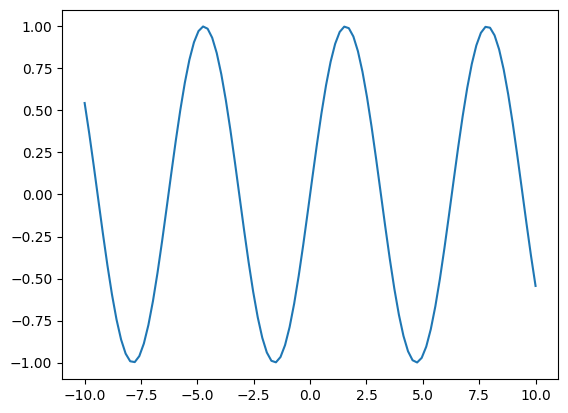

In [4]:
plt.plot(x, y)


### 【練習】函數畫圖

這次我們來畫:

$$f(x) = \frac{\sin(5x)}{1+x^2}$$

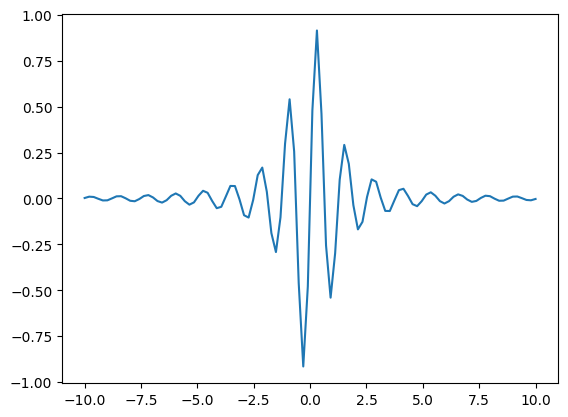

In [5]:
y = np.sin(5*x) / (1 + x**2)
plt.plot(x, y)


## 2 快速改變風格

雖然 `matplotlib` 在很辛苦的調校之後也是可以畫美美的圖, 不過它比較是「讓我們快速看到結果」的套件。所以它有些快速基本修飾功能。

### 【技巧】快速改變顏色

![快取色彩](images/color.png)

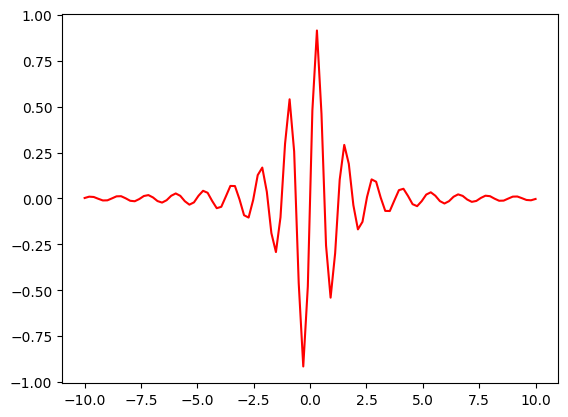

In [6]:
plt.plot(x, y, "r")


### 【技巧】快速改變線條風格

快速改變線條風格, 還可和顏色混用。

| 參數 | 說明 |
|---|---|
| `--` | dash |
| `-.` | 點 + dash |
| `:` | 點點 |
| `o` | 大點點 |
| `^` | 三角 |
| `s` | 方塊 |

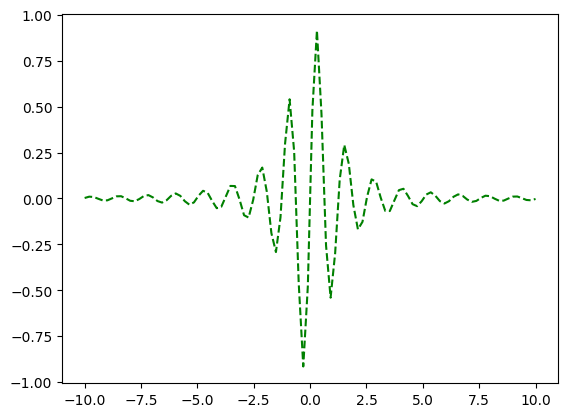

In [7]:
plt.plot(x, y, "g--")


## 3 基本的修飾

| 參數 | 說明 |
|---|---|
| `alpha` | 透明度 |
| `color` (`c`)| 顏色 |
| `linestyle` (`ls`) | 線條風格 |
| `linewidth` (`lw`) | 線寬 |

Text(0.5, 1.0, 'Function plot')

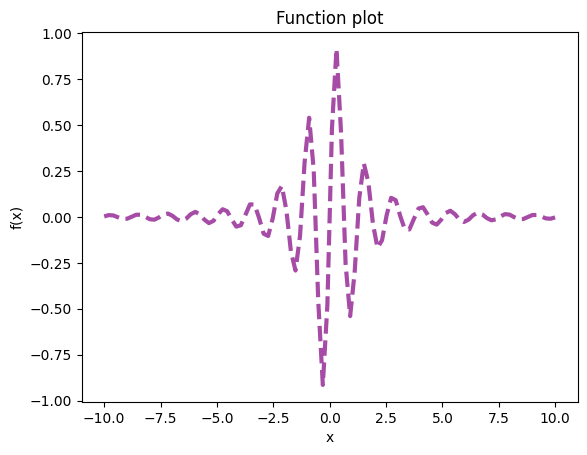

In [8]:
plt.plot(x, y, color="purple", linestyle="--", linewidth=3, alpha=0.7)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Function plot")


## 4 如果畫個參數式圖形

其實參數式圖形基本上也是一堆 x, y 的座標, 只是 x(t), y(t) 都是 t 的函數, 我們可以想成 t 是時間。

假設我們的

$$ -2\pi \leq t \leq 2\pi$$

要畫個半徑是 r 的圓, x(t), y(t) 就是這樣:

* $x(t) = r\cos(t)$
* $y(t) = r\sin(t)$

我們來試試事情是不是如我們想的這樣...

In [9]:
t = np.linspace(-2*np.pi, 2*np.pi, 500)


In [10]:
x = np.cos(t)
y = np.sin(t)


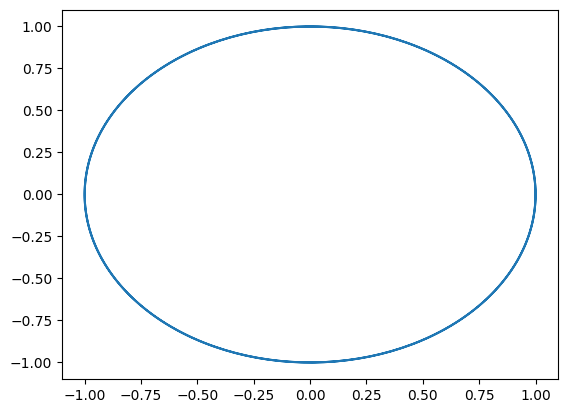

In [11]:
plt.plot(x, y)


真的成功了... 等等, `matplotlib` 怎麼畫成橢圓呢? 我們來調整一下。

(np.float64(-1.0999791907454364),
 np.float64(1.099999009083116),
 np.float64(-1.0999945499436368),
 np.float64(1.0999945499436368))

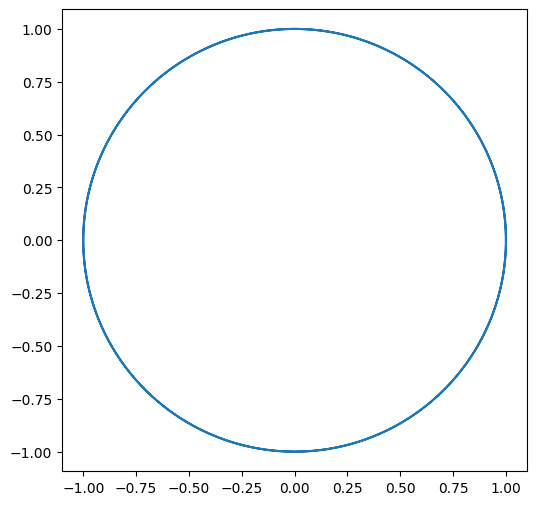

In [12]:
plt.figure(figsize=(6, 6))
plt.plot(x, y)
plt.axis("equal")


再來我們可以想一下, 如果 r 不是故定的呢? 也就是它會變長變短, 是不是會畫出很多特別的圖呢? 其實很多特別的曲線不過就是找個試合的 r(t), 我們來隨意試試看。

(np.float64(-2.128928975032549),
 np.float64(2.1287130712986766),
 np.float64(-2.128479958312687),
 np.float64(2.128996577407768))

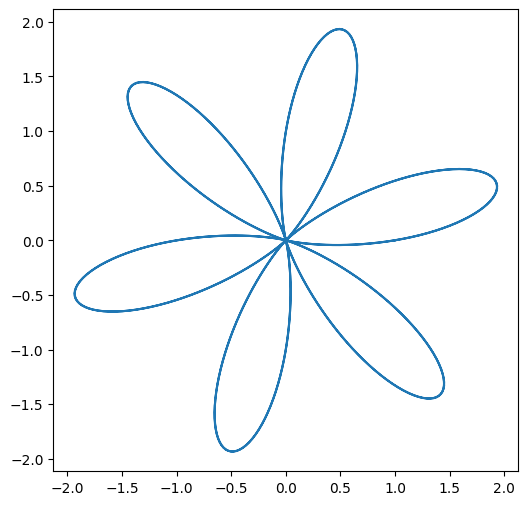

In [13]:
r = 1 + np.sin(6*t)
x = r * np.cos(t)
y = r * np.sin(t)
plt.figure(figsize=(6, 6))
plt.plot(x, y)
plt.axis("equal")


是不是很有意思呢? 你也可以自己試試不同的變化。

## 5 `subplot` 畫多個圖

我們每次畫圖的時候, `matplotlib` 就弄 1 個 figure 畫圖區出來, 裡面可以有很多子圖, 在 figure 裡叫 axes。目前我們都只有 1 個 figure 內含 1 張圖, 所以都不用設, 現在我想畫 4 張圖時。我們就要先想好「陣式」。

比如說 2x2 這樣排列的 4 張圖。

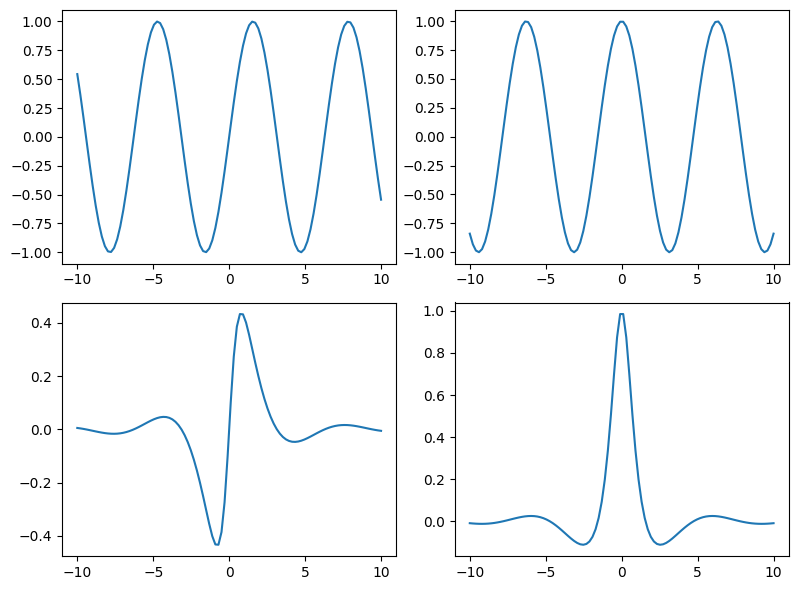

In [14]:
x = np.linspace(-10, 10, 100)
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes[0, 0].plot(x, np.sin(x))
axes[0, 1].plot(x, np.cos(x))
axes[1, 0].plot(x, np.sin(x)/(1+x**2))
axes[1, 1].plot(x, np.cos(x)/(1+x**2))
plt.tight_layout()


## 6 進階色彩*

#### 顏色表示法 1

    c = 'r' 

可以用 blue (b), green (g), red (r), cyan (c), magenta (m), yellow (y), black (k), white (w)


#### 顏色表示法 2

用一個 0 到 1 的數字表灰階, 越大越白。

    c = '0.6'
    
#### 顏色表示法 3

網頁常用的標準 16 進位 RGB 表示法。

    c = '#00a676'
    
我們怎知哪裡可選顏色呢? 可以用之前彥良介紹的 [Coolors.co](https://coolors.co) 等。
    
#### 顏色表示法 4

用 0-1 的數字表 RGB 也可以。

    c=(0.7, 0.4, 1)

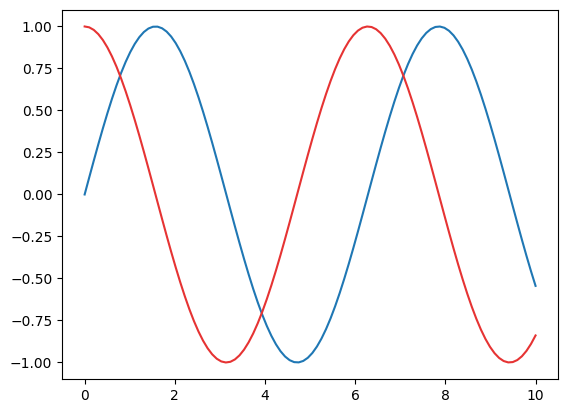

In [15]:
x = np.linspace(0, 10, 100)
plt.plot(x, np.sin(x), c="#1f77b4")
plt.plot(x, np.cos(x), c=(0.9, 0.2, 0.2))


## 7 Marker*

所謂 'marker' 就是原來的點, 我們特別標示出來, 為了不要讓圖形太複雜, 我們新換個點比較少的例子。

In [16]:
x = np.linspace(0, 10, 20)
y = np.sin(x)


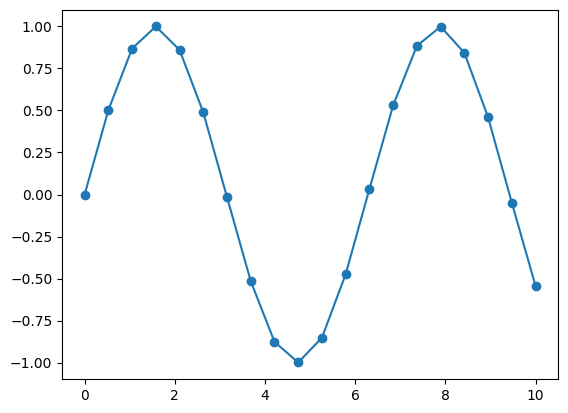

In [17]:
plt.plot(x, y, marker="o")


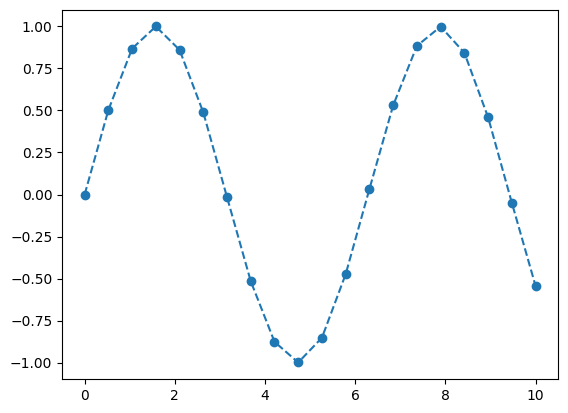

In [18]:
plt.plot(x, y, "o--")


#### marker 可以設的參數

| 參數 | 說明 |
|---|---|
| `marker` | marker 的風格 |
| `markeredgecolor` (`mec`) | 邊線顏色 |
| `markeredgewidth` (`mew`) | 邊線寬度 |
| `markerfacecolor` (`mfc`) | marker 的顏色 |
| `markerfacecoloralt` (`mfcalt`) | marker 替換色 |
| `markersize` (`ms`) | marker 大小 |
| `markevery` | 隔多少畫一個 marker |

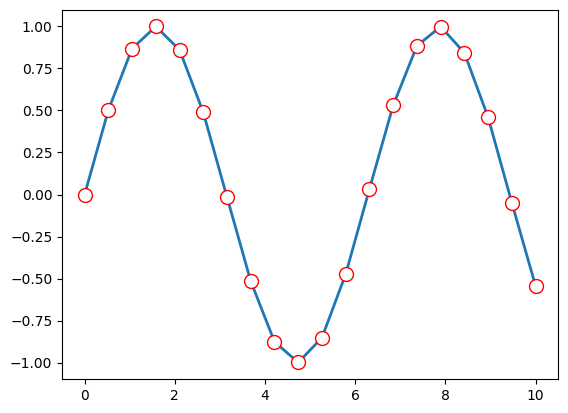

In [19]:
plt.plot(x, y, marker="o", markerfacecolor="white", markeredgecolor="red", markersize=10, linewidth=2)


比較奇特的參數是 `markevery`, 這是說我們每多少筆資料要畫一個 marker。為了示範, 我們拿之前的例子來看看。

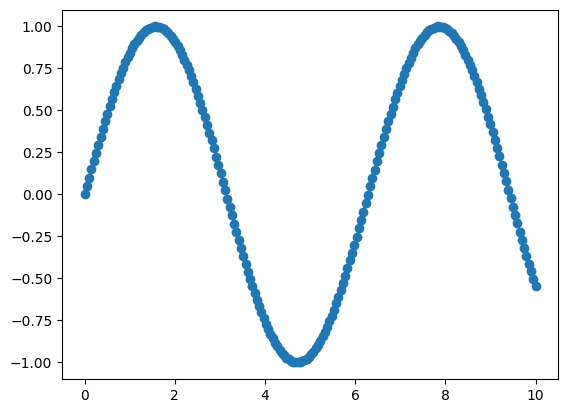

In [20]:
x = np.linspace(0, 10, 200)
y = np.sin(x)
plt.plot(x, y, marker="o")


後面的完完全全連在一起了, 我們現在隔 10 個畫一個 marker 試試。

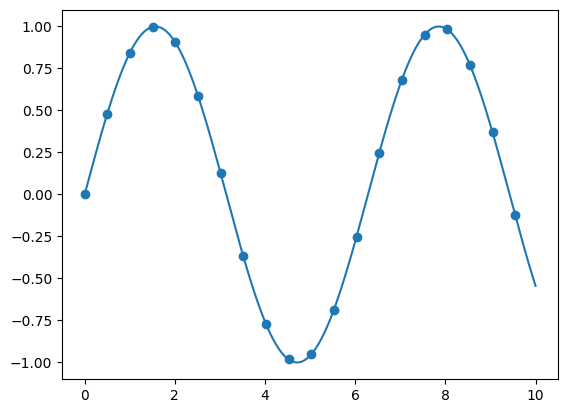

In [21]:
plt.plot(x, y, marker="o", markevery=10)


## 8 bar 風*

<BarContainer object of 5 artists>

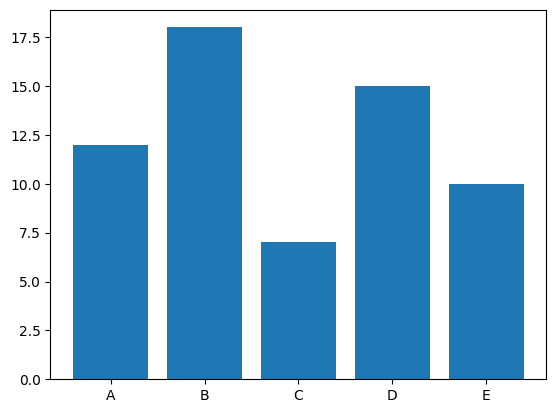

In [22]:
labels = ["A", "B", "C", "D", "E"]
values = [12, 18, 7, 15, 10]
plt.bar(labels, values)


移一點點。

([<matplotlib.axis.XTick at 0x2df63623390>,
 [Text(0, 0, 'A'),
  Text(1, 0, 'B'),
  Text(2, 0, 'C'),
  Text(3, 0, 'D'),
  Text(4, 0, 'E')])

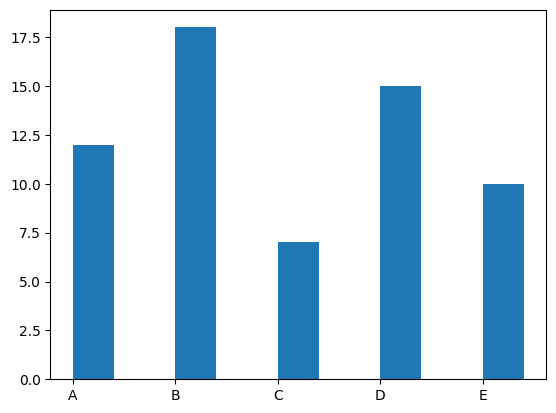

In [23]:
xpos = np.arange(len(labels))
plt.bar(xpos + 0.2, values, width=0.4)
plt.xticks(xpos, labels)


#### 雙色的長條圖

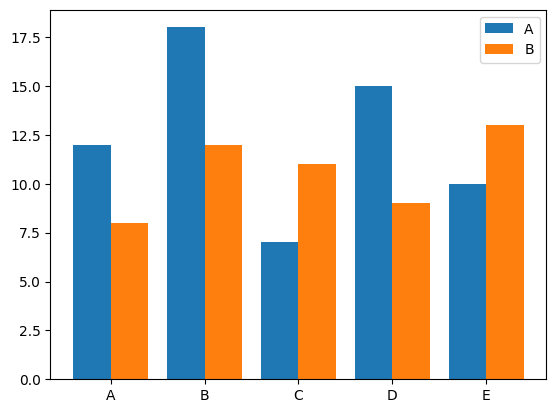

In [24]:
values2 = [8, 12, 11, 9, 13]
plt.bar(xpos - 0.2, values, width=0.4, label="A")
plt.bar(xpos + 0.2, values2, width=0.4, label="B")
plt.xticks(xpos, labels)
plt.legend()


#### 疊加型的資料

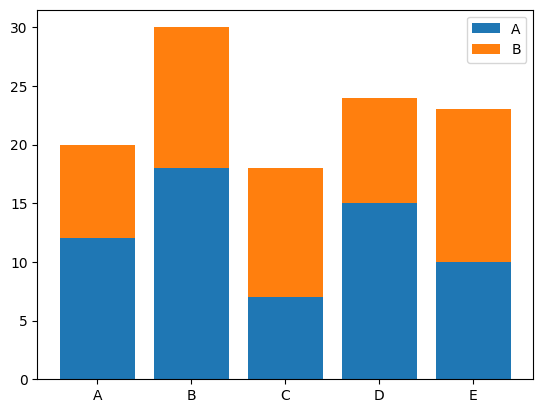

In [25]:
plt.bar(labels, values, label="A")
plt.bar(labels, values2, bottom=values, label="B")
plt.legend()


#### 橫放的長條圖

<BarContainer object of 5 artists>

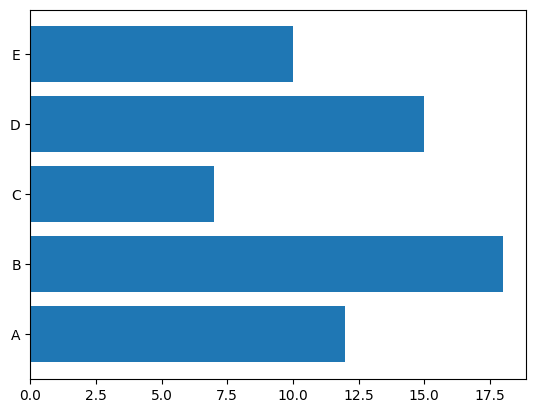

In [26]:
plt.barh(labels, values)


#### 雙向的長條圖

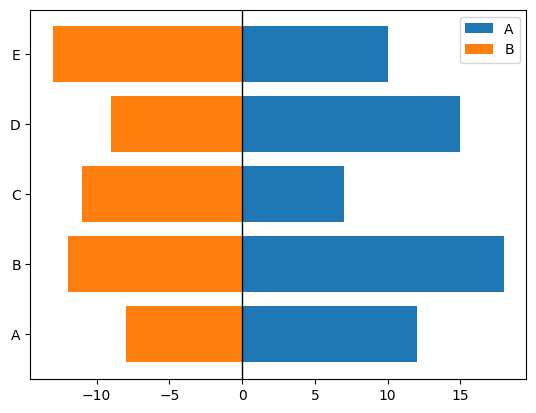

In [27]:
plt.barh(labels, values, label="A")
plt.barh(labels, [-v for v in values2], label="B")
plt.axvline(0, color="black", linewidth=1)
plt.legend()


## 9 畫圖區的設定*

#### 說明文字的標示

Text(3, 1.25, 'max')

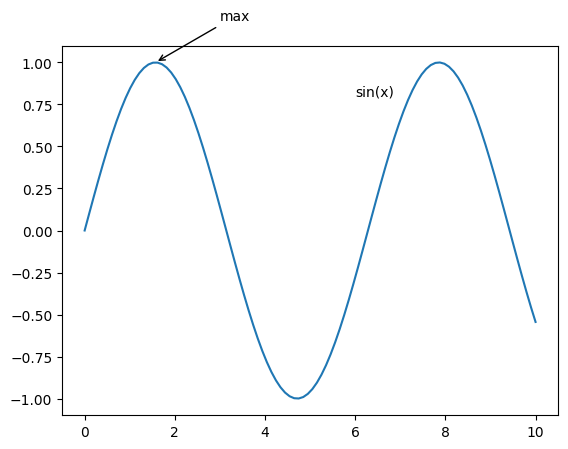

In [28]:
x = np.linspace(0, 10, 100)
y = np.sin(x)
plt.plot(x, y)
plt.text(6, 0.8, "sin(x)")
plt.annotate("max", xy=(np.pi/2, 1), xytext=(3, 1.25), arrowprops=dict(arrowstyle="->"))


Text(0, 0.5, 'sin(x)')

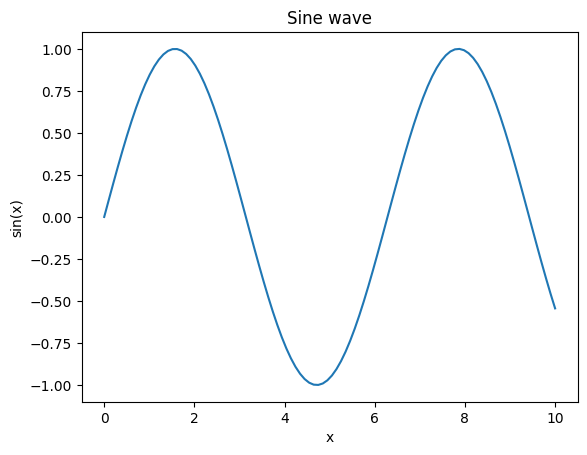

In [29]:
plt.plot(x, y)
plt.title("Sine wave")
plt.xlabel("x")
plt.ylabel("sin(x)")


#### 邊界的設定

(-1.2, 1.2)

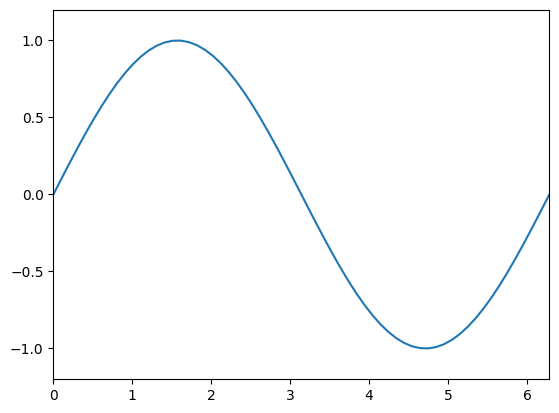

In [30]:
plt.plot(x, y)
plt.xlim(0, 2*np.pi)
plt.ylim(-1.2, 1.2)


#### xticks

([<matplotlib.axis.XTick at 0x2df63956210>,
 [Text(1, 0, '?'),
  Text(2, 0, '?'),
  Text(3, 0, '?'),
  Text(4, 0, '?'),
  Text(5, 0, '?')])

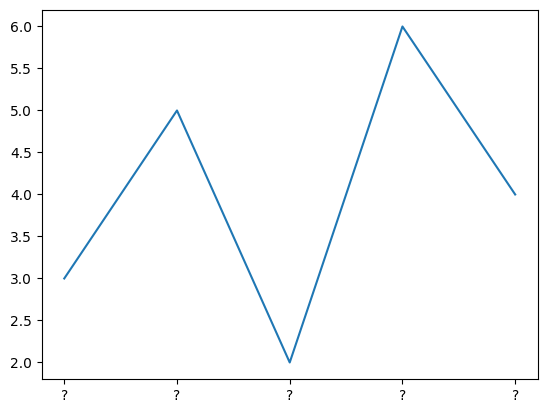

In [31]:
plt.plot([1,2,3,4,5], [3,5,2,6,4])
plt.xticks([1,2,3,4,5], ["?", "?", "?", "?", "?"])


# [練習]自己生成測試數據，X軸xticks對應到y軸數值

例如: 1,2,3,4,5 對應X軸 '甲','乙'...

#### 圖例 legend

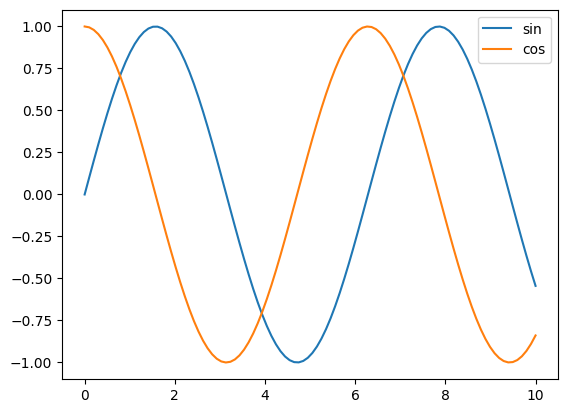

In [32]:
plt.plot(x, np.sin(x), label="sin")
plt.plot(x, np.cos(x), label="cos")
plt.legend()


可用 `loc` 去設圖例的位置, 依 1, 2, 3, ... 表示。

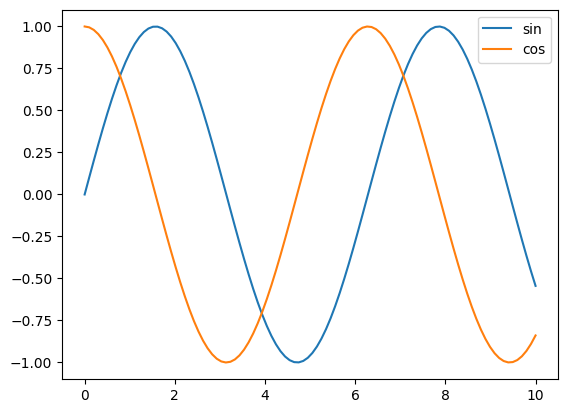

In [33]:
plt.plot(x, np.sin(x), label="sin")
plt.plot(x, np.cos(x), label="cos")
plt.legend(loc=1)


## 10 取得現在工作中 axes*

我們有時要設 axes 的背景啦等等的資訊。這時就要取得現在工作中的 axes。這一般有兩種方式, 第一種是設 `subplot` 時可以取得:

    fig, ax = plt.subplot()
    
另一種是用 `gca` 函數:

    ax = plt.gca()

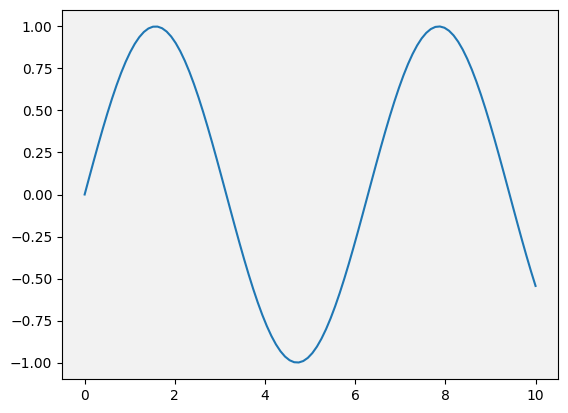

In [34]:
fig, ax = plt.subplots()
ax.plot(x, np.sin(x))
ax.set_facecolor("#f2f2f2")


#### 移動 x, y 座標軸

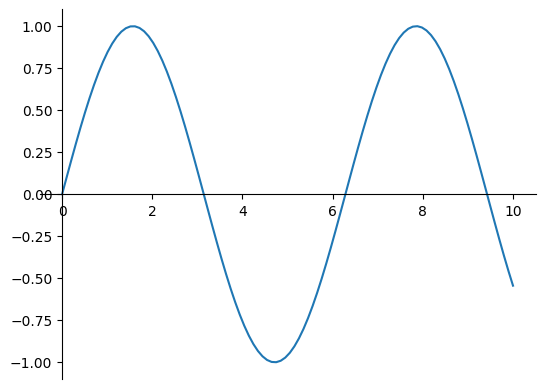

In [35]:
fig, ax = plt.subplots()
ax.plot(x, np.sin(x))
ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")
ax.spines["right"].set_color("none")
ax.spines["top"].set_color("none")


## 11 耍寶可愛的 `xkcd`*

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd S

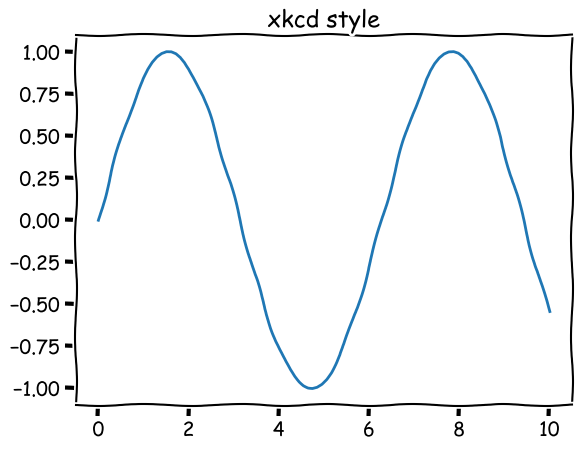

In [36]:
with plt.xkcd():
    plt.plot(x, np.sin(x))
    plt.title("xkcd style")


Text(0.5, 1.0, 'Back to normal')

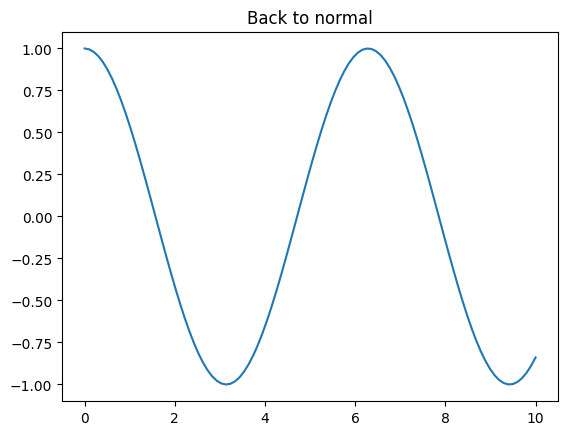

In [37]:
plt.plot(x, np.cos(x))
plt.title("Back to normal")


## 12 `seaborn` 大救星

雖然 `matplotlib` 幾乎什麼都可以調, 但有些簡單的調整卻要花費很多時間。於是有了許多可以協助 `matplotlib` 變美、變方便的套件出現。最近有個很有名的叫 `seaborn`, 儼然有另一個標準套件的態式。

最重要的是 `seaborn` 和我們未來要介紹的 `pandas` 配合得非常好, 雖然熊貓和海生的聽來就沒什麼關係...

我們先來個標準 (又來標準縮寫) 讀入 `seaborn` 的方法。

In [38]:
import seaborn as sns
sns.set_theme()


然後像平常畫個圖。

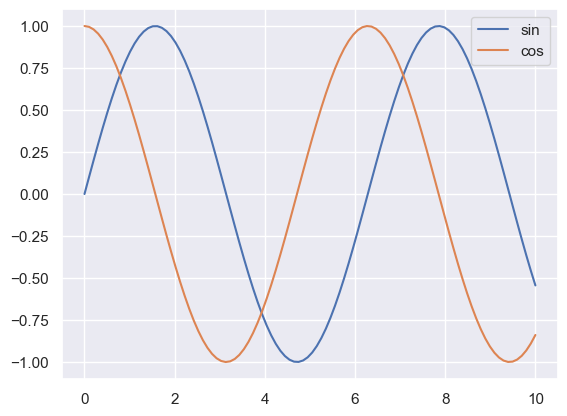

In [39]:
plt.plot(x, np.sin(x), label="sin")
plt.plot(x, np.cos(x), label="cos")
plt.legend()


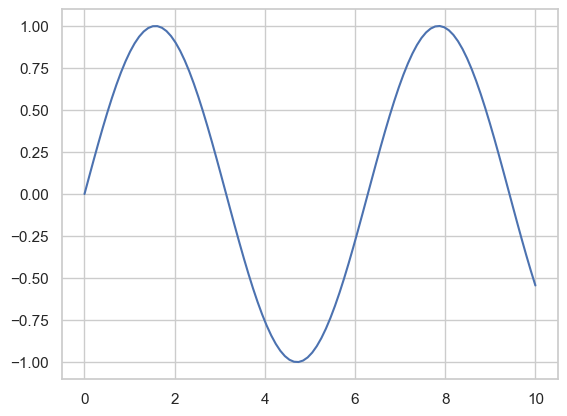

In [40]:
sns.set_style("whitegrid")
plt.plot(x, np.sin(x))


傑克, 這真是太神奇了!

總之, 你根本就直接用原來 `matplotlib` 的指令, 馬上 `seaborn` 就會幫你美化。當然我們還是可以做更多的控制, 詳情請參考

[seaborn 的網站](https://seaborn.github.io/)

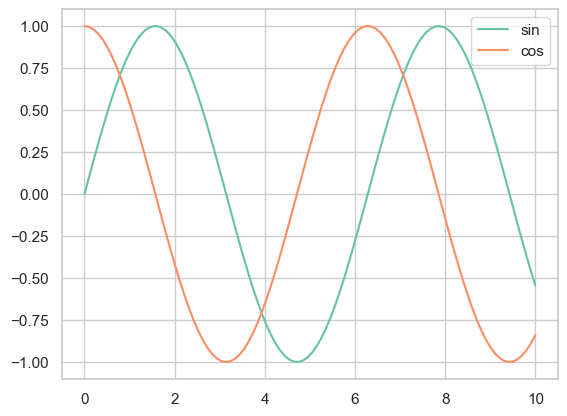

In [41]:
sns.set_palette("Set2")
plt.plot(x, np.sin(x), label="sin")
plt.plot(x, np.cos(x), label="cos")
plt.legend()


In [42]:
sns.reset_defaults()
